# Skin Lesion Classification using CNN

## Semester Project – Programming for AI

### Team Members
- bscs24043 Ibrahim Butt
- bscs24095 Waize Arif
- bscs24139 Syed Jaffar Raza Kazmi
- bscs24083 Muhammad Moiz

### Objective
Build a Convolutional Neural Network (CNN) model to classify skin lesion images.

# Python Imports

In [15]:
!pip install torchmetrics

import torch
import torchvision
from torch.utils.data import DataLoader, Subset
import torchmetrics
from torchmetrics import ConfusionMatrix
import matplotlib.pyplot as plt
import numpy as np
from torch import nn
from timeit import default_timer as timer
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split



In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
!cp "/content/drive/MyDrive/skin_lesion/skin_dataset.zip" "/content/"

!unzip -q "/content/skin_dataset.zip" -d "/content/"

!ls "/content/dataset"

replace /content/dataset/healthy/healthy_100.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
acne  bruises  burn  healthy  pigmentation


# Check Version and Device

In [18]:
print(f"PyTorchColab Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

PyTorchColab Version: 2.10.0+cu128
Torchvision Version: 0.25.0+cu128
Using device: cuda


# HyperParameters

In [19]:
# --- HYPERPARAMETER DASHBOARD ---

SEED = 42                # seed for reproducibility
TRAIN_SPLIT = 0.8        # train test split value, 80% train, 20% test
BATCH_SIZE = 32          # lower if model getting stuck
LEARNING_RATE = 0.0005   # rate of learning
EPOCHS = 40              # Itterations, more for difficult learning
DROPOUT_RATE = 0.3       # Kills 30% of neurons randomly to stop memorization
IMAGE_SIZE = 224         # image size

# Transformin data

In [20]:
# DATA TRANSFORMING

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomVerticalFlip(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])
print("Transforms defined successfully.")

Transforms defined successfully.


# Data Loading

In [21]:
dataset_path = "/content/dataset"

train_data_full = ImageFolder(root=dataset_path, transform=train_transforms)
test_data_full  = ImageFolder(root=dataset_path, transform=test_transforms)

# 80 20 split
total_images = len(train_data_full)
train_count = int(TRAIN_SPLIT * total_images)

# Generate a shared list of shuffled numbers

indices = torch.randperm(total_images).tolist()

# train and test sets
train_dataset = Subset(train_data_full, indices[:train_count])
test_dataset  = Subset(test_data_full, indices[train_count:])

# Loaders made
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Data loaded correctly. Train and Test are safely separated.")

Data loaded correctly. Train and Test are safely separated.


# The CNN class

In [22]:
import torch.nn as nn

class SkinCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(DROPOUT_RATE)

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, 5)

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))

        x = self.flatten(x)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SkinCNN().to(device)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("CNN built and pushed to GPU.")


CNN built and pushed to GPU.


# Training Loop

In [23]:
loss_history = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss/len(train_loader)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {epoch_loss:.4f}")

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nFinal Test Accuracy: {100 * correct / total:.2f}%")

Epoch 1/40 | Loss: 8.4122
Epoch 2/40 | Loss: 3.0726
Epoch 3/40 | Loss: 2.1040
Epoch 4/40 | Loss: 1.4777
Epoch 5/40 | Loss: 1.2845
Epoch 6/40 | Loss: 1.1756
Epoch 7/40 | Loss: 1.1543
Epoch 8/40 | Loss: 1.0703
Epoch 9/40 | Loss: 1.0438
Epoch 10/40 | Loss: 0.9612
Epoch 11/40 | Loss: 0.9277
Epoch 12/40 | Loss: 0.9015
Epoch 13/40 | Loss: 0.8449
Epoch 14/40 | Loss: 0.8761
Epoch 15/40 | Loss: 0.8078
Epoch 16/40 | Loss: 0.7283
Epoch 17/40 | Loss: 0.7531
Epoch 18/40 | Loss: 0.7244
Epoch 19/40 | Loss: 0.6981
Epoch 20/40 | Loss: 0.6396
Epoch 21/40 | Loss: 0.6163
Epoch 22/40 | Loss: 0.5681
Epoch 23/40 | Loss: 0.6436
Epoch 24/40 | Loss: 0.6442
Epoch 25/40 | Loss: 0.5923
Epoch 26/40 | Loss: 0.5475
Epoch 27/40 | Loss: 0.5425
Epoch 28/40 | Loss: 0.5592
Epoch 29/40 | Loss: 0.6030
Epoch 30/40 | Loss: 0.5132
Epoch 31/40 | Loss: 0.4830
Epoch 32/40 | Loss: 0.5055
Epoch 33/40 | Loss: 0.5350
Epoch 34/40 | Loss: 0.5317
Epoch 35/40 | Loss: 0.4397
Epoch 36/40 | Loss: 0.4402
Epoch 37/40 | Loss: 0.4537
Epoch 38/4

# Accuracy and Prediction checking

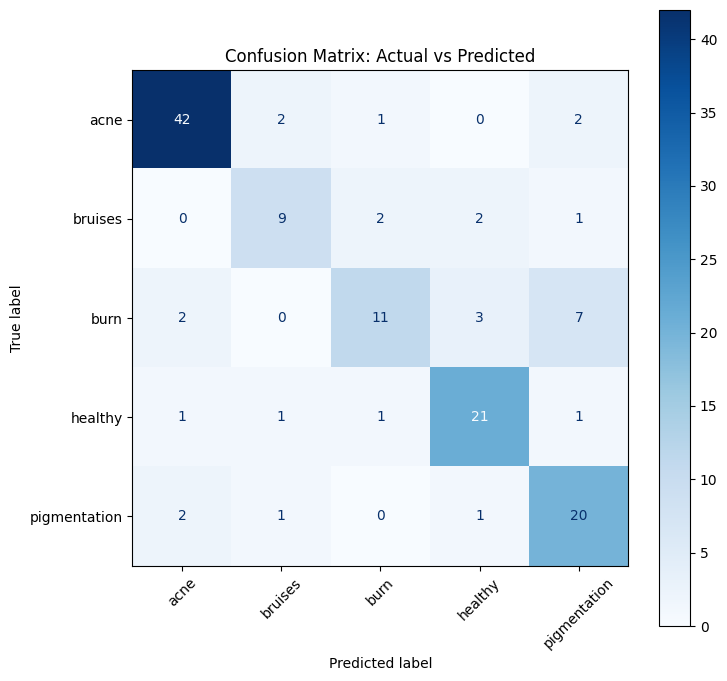

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data_full.classes)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title("Confusion Matrix: Actual vs Predicted")
plt.show()

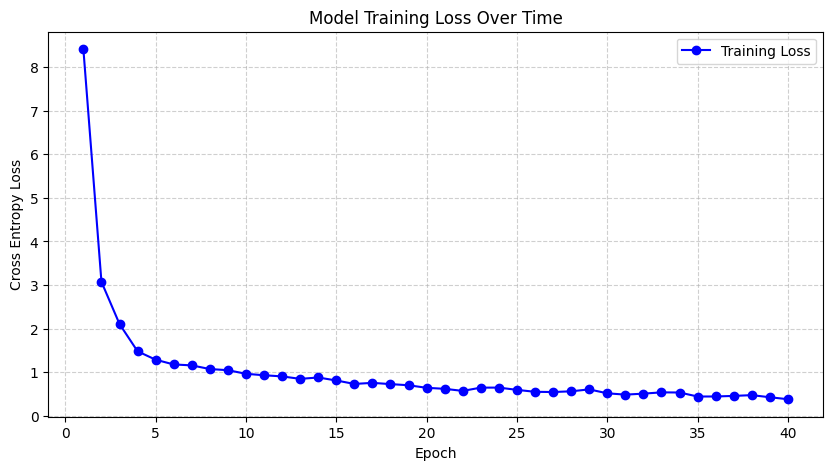

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS + 1), loss_history, marker='o', color='b', label='Training Loss')
plt.title("Model Training Loss Over Time")
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [ ]:
# batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)

# Make predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images = images.cpu()

# Plot images
fig = plt.figure(figsize=(15, 6))
for idx in range(6):
    ax = fig.add_subplot(1, 6, idx+1, xticks=[], yticks=[])

    img = images[idx] / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

    true_label = train_data_full.classes[labels[idx]]
    pred_label = train_data_full.classes[preds[idx]]

    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontweight='bold')

plt.tight_layout()
plt.show()